c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.481e+11, tolerance: 7.873e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.670e+11, tolerance: 8.022e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

Best Params {'lasso__alpha': 100}
Toplam Özellik: 111
Elenen (Sıfırlanan) Özellik Sayısı: 22
R2: 0.88267855832767
MAE: 16105.968473282692
RMSE: 23492.044183471036


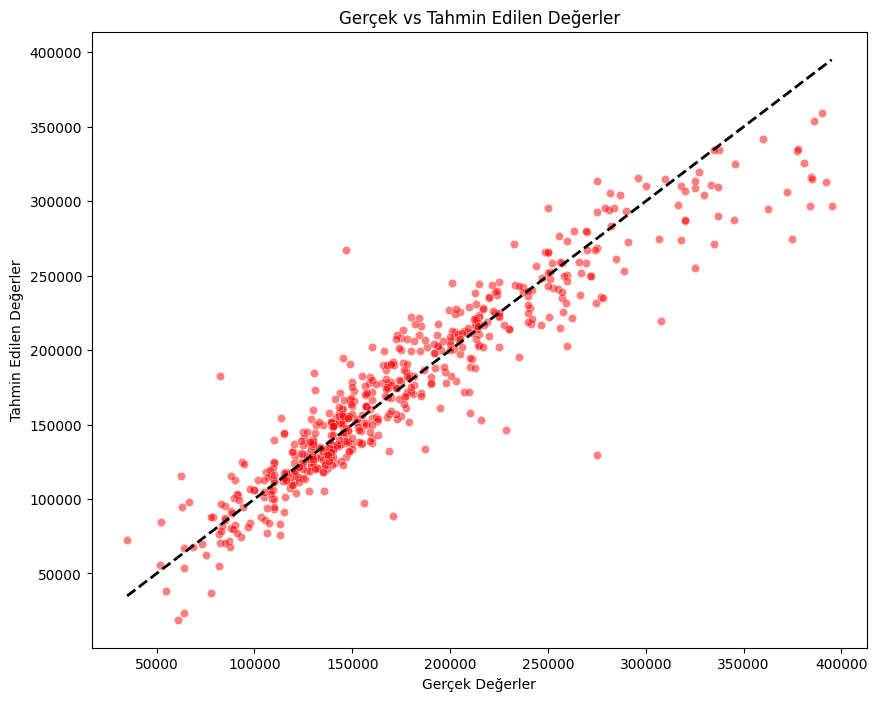

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Ames_Housing_Processed.csv")


X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

steps = [
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
]

pipeline = Pipeline(steps)

param_grid = {
    'lasso__alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print("Best Params", grid_search.best_params_)

y_pred = grid_search.predict(X_test)

best_lasso = grid_search.best_estimator_.named_steps['lasso']

coeffs = best_lasso.coef_


eliminated_features = np.sum(coeffs == 0)
total_features = len(coeffs)

print(f"Toplam Özellik: {total_features}")
print(f"Elenen (Sıfırlanan) Özellik Sayısı: {eliminated_features}")


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"R2: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', lw=2, linestyle='--')
plt.xlabel("Actual Sale Prices ($)")
plt.ylabel("Predicted Sale Prices ($)")
plt.title("Actual vs. Predicted Housing Prices (Stacking Ensemble)")
plt.show()
